# Fashion MNIST CNN Classification

This project builds a Convolutional Neural Network (CNN) to classify Fashion MNIST clothing images into 10 categories.

The project demonstrates an end-to-end image classification workflow, including data loading, preprocessing, CNN model building, training, evaluation, prediction visualization, and error analysis.

## Project Workflow

1. Import required libraries
2. Load the Fashion MNIST dataset
3. Define and verify class names
4. Display sample Fashion MNIST images
5. Normalize image pixel values
6. Reshape images for CNN input
7. Build the CNN model
8. Compile the model
9. Train the model
10. Evaluate the model on test data
11. Plot training and validation accuracy/loss
12. Generate predictions
13. Review the classification report
14. Display the confusion matrix
15. Visualize sample model predictions
16. Review misclassified images
17. Summarize findings

# Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

# Step 2: Load Fashion MNIST Dataset

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


# Step 3: Define Class Names

In [10]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [15]:
for index, name in enumerate(class_names):
    print(index, "=", name)

0 = T-shirt/top
1 = Trouser
2 = Pullover
3 = Dress
4 = Coat
5 = Sandal
6 = Shirt
7 = Sneaker
8 = Bag
9 = Ankle boot


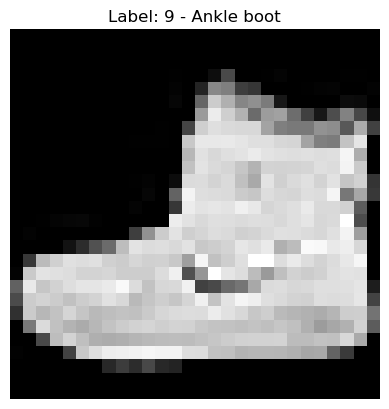

In [17]:
# The first training image
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]} - {class_names[y_train[0]]}")
plt.axis("off")
plt.show()

### Explanation

Fashion MNIST labels are stored as numeric values from 0 to 9. Each number represents one clothing category.

The `class_names` list is used to convert each numeric label into a readable clothing name. For example, label `9` corresponds to `Ankle boot`.

In this example, the first training image has the numeric label `9`, so `class_names[y_train[0]]` returns `Ankle boot`. The image shown confirms that the label matches the clothing item.

# Step 4: Display Sample Images

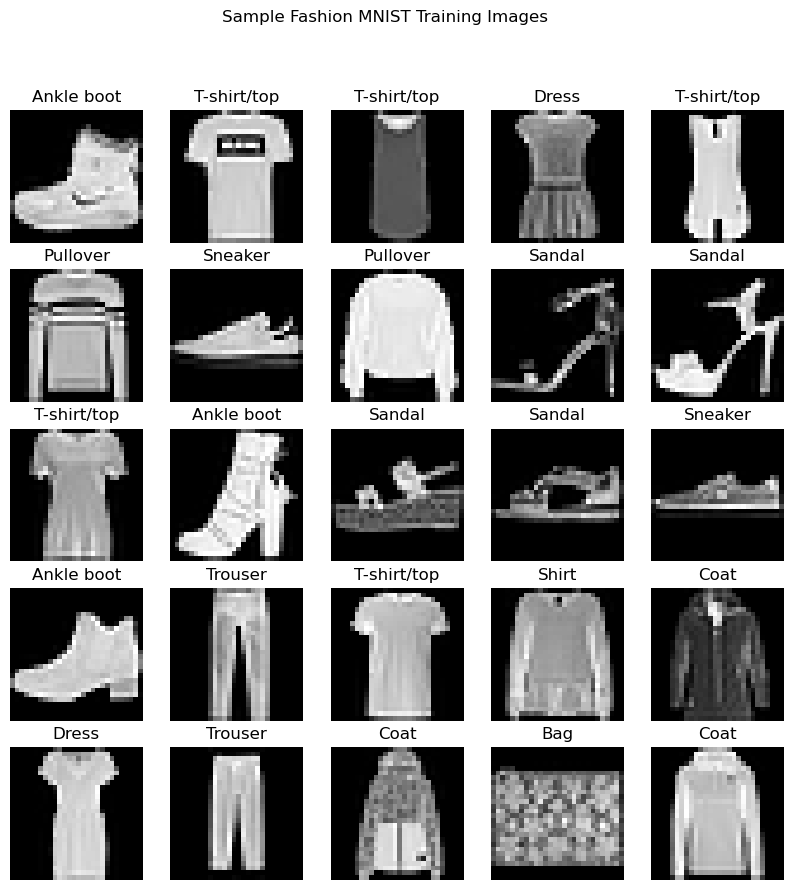

In [18]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Sample Fashion MNIST Training Images")
plt.show()

### Explanation

This step displays 25 sample images from the Fashion MNIST training dataset.

Each image is shown in grayscale using `cmap="gray"` because Fashion MNIST images are single-channel grayscale images.

The title above each image shows the clothing class name. The numeric label from `y_train[i]` is converted into a readable class name using:

`class_names[y_train[i]]`

For example, if `y_train[i]` is `9`, then `class_names[9]` displays `Ankle boot`.

This visualization helps confirm that the images and labels are correctly loaded before training the CNN model.

# Step 5: Normalize Image Data

In [19]:
print("Pixel value range before normalization:", x_train.min(), "to", x_train.max())

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Pixel value range after normalization:", x_train.min(), "to", x_train.max())

Pixel value range before normalization: 0 to 255
Pixel value range after normalization: 0.0 to 1.0


### Explanation

The original Fashion MNIST image pixel values range from 0 to 255.

- `0` represents black or very dark pixels.
- `255` represents white or very bright pixels.

The image data is normalized by dividing each pixel value by `255.0`. This changes the pixel value range from `0–255` to `0–1`.

Normalization helps the neural network train more efficiently because the input values become smaller and more consistent. This can improve training stability and help the model learn patterns faster.

After normalization, the pixel values range from `0.0` to `1.0`, which confirms that the preprocessing step worked correctly.

# Step 6: Reshape for CNN Input

In [20]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New training shape:", x_train.shape)
print("New testing shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New testing shape: (10000, 28, 28, 1)


### Explanation

Before reshaping, each Fashion MNIST image has the shape `28 × 28`.

A CNN model expects image data in this format:

`(number of images, height, width, channels)`

Because Fashion MNIST images are grayscale, each image has only **1 channel**. Therefore, the images are reshaped from:

`(60000, 28, 28)`

to:

`(60000, 28, 28, 1)`

for training data, and from:

`(10000, 28, 28)`

to:

`(10000, 28, 28, 1)`

for testing data.

The final `1` represents the single grayscale channel. This reshaping step is required so the images can be used correctly by the CNN layers.

# Step 7: Build CNN Model

In [21]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(10, activation="softmax")
])

### Explanation

This step builds a Convolutional Neural Network (CNN) for Fashion MNIST image classification.

The model uses convolutional layers to learn visual patterns from clothing images, such as edges, curves, textures, and shapes. Max pooling layers reduce the size of the feature maps while keeping the most important information.

The model architecture works as follows:

- `Input`: Defines the image shape as `28 × 28 × 1`, where `1` means one grayscale channel.
- `Conv2D(32, (3, 3))`: Uses 32 filters to detect simple visual patterns such as edges and basic clothing outlines.
- `MaxPooling2D((2, 2))`: Reduces the feature map size and keeps the strongest features.
- `Conv2D(64, (3, 3))`: Uses 64 filters to learn more detailed image patterns.
- `MaxPooling2D((2, 2))`: Reduces the feature map size again.
- `Conv2D(64, (3, 3))`: Adds another convolution layer to learn deeper clothing features.
- `Flatten`: Converts the 2D feature maps into a 1D vector.
- `Dense(128)`: Learns classification patterns from the extracted image features.
- `Dropout(0.4)`: Randomly disables 40% of neurons during training to reduce overfitting.
- `Dense(10, softmax)`: Outputs probability scores for the 10 Fashion MNIST classes.

The final `softmax` layer is used because this is a multi-class classification problem. The class with the highest probability becomes the model's final prediction.

# Step 8: Compile the Model

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

### Explanation

This step prepares the CNN model for training.

- `optimizer="adam"`: Adam is used to update the model weights during training. It is commonly used because it adapts the learning rate and works well for many neural network problems.
- `loss="sparse_categorical_crossentropy"`: This loss function is used for multi-class classification when the labels are stored as integers. In Fashion MNIST, the labels are numbers from 0 to 9.
- `metrics=["accuracy"]`: Accuracy is used to measure how often the model predicts the correct clothing class.

The `model.summary()` output shows the structure of the CNN model, including each layer, output shape, and number of parameters.

The final layer has an output shape of `(None, 10)` because the model predicts one of 10 Fashion MNIST clothing classes.

The model has 130,890 trainable parameters. These are the values the model learns and updates during training.

# Step 9: Train the Model

In [24]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - accuracy: 0.7668 - loss: 0.6358 - val_accuracy: 0.8468 - val_loss: 0.4015
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8576 - loss: 0.3918 - val_accuracy: 0.8702 - val_loss: 0.3421
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.8791 - loss: 0.3332 - val_accuracy: 0.8893 - val_loss: 0.2915
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step - accuracy: 0.8906 - loss: 0.2989 - val_accuracy: 0.8975 - val_loss: 0.2773
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9005 - loss: 0.2742 - val_accuracy: 0.8990 - val_loss: 0.2743
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.9067 - loss: 0.2544 - val_accuracy: 0.9057 - val_loss: 0.2578
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9140 - loss: 0.2372 - val_accuracy: 0.9033 - val_loss: 0.2609
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9184 - loss: 0.2196 - 

### Explanation

This step trains the CNN model using the Fashion MNIST training data.

- `x_train`: The normalized and reshaped training images.
- `y_train`: The correct clothing labels for the training images.
- `epochs=10`: The model goes through the full training dataset 10 times.
- `batch_size=64`: The model updates its weights after processing 64 images at a time.
- `validation_split=0.1`: 10% of the training data is used for validation during training.

During training, the model learns by comparing its predictions with the true labels and adjusting its weights to reduce the loss.

The training results show that the model improved over time. The training accuracy increased from about 76.68% in epoch 1 to about 92.96% in epoch 10. The validation accuracy also improved and reached about 90.97%.

The training loss decreased from about 0.6358 to 0.1916, which means the model’s prediction error became smaller as training continued.

Overall, the model is learning well. Fashion MNIST is more difficult than handwritten digit MNIST because some clothing categories look similar, such as shirts, coats, and pullovers.

# Step 10: Evaluate the Model

In [25]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9053 - loss: 0.2684
Test Loss: 0.2684
Test Accuracy: 0.9053


### Explanation

This step evaluates the trained CNN model using the test dataset.

The test dataset contains images that were not used during training. This helps check how well the model performs on new, unseen data.

- `test_loss`: Measures the model's prediction error on the test data. A lower loss means better performance.
- `test_accuracy`: Measures the percentage of test images that the model classified correctly.

The model achieved a test accuracy of approximately `90.53%`, which means it correctly classified about 90 out of every 100 Fashion MNIST test images.

The test loss is approximately `0.2684`, which shows the model has a relatively low prediction error on unseen data.

Fashion MNIST is more challenging than digit MNIST because some clothing categories have similar shapes, such as shirts, coats, and pullovers. Therefore, a test accuracy around 90% is a reasonable result for this CNN model.

# Step 11: Plot Training Accuracy and Loss

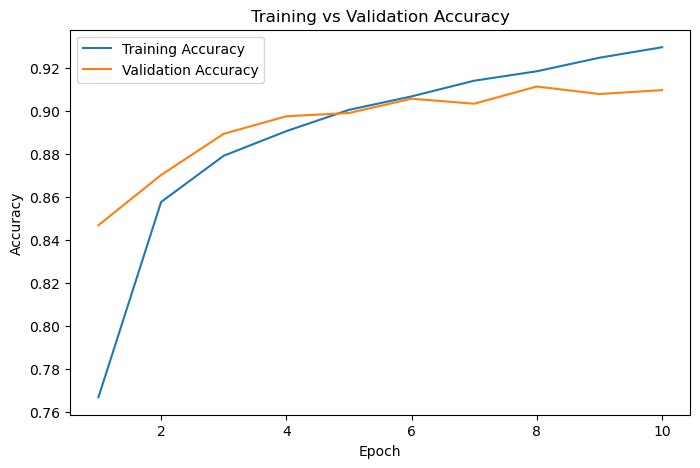

In [26]:
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

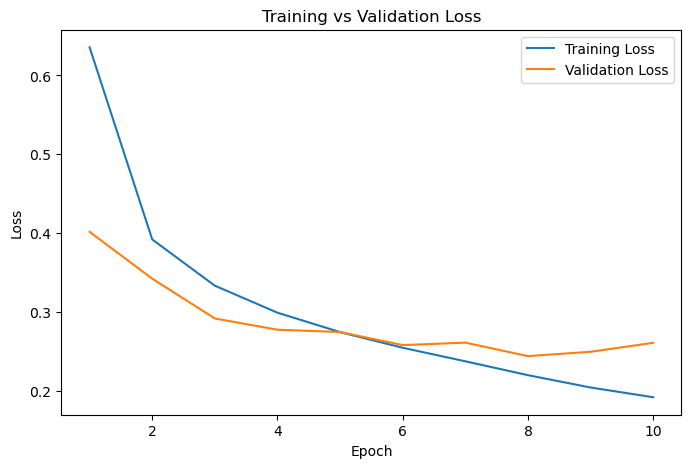

In [27]:
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### Explanation

These plots show how the model performed during training.

The accuracy plot shows whether the model became better at classifying Fashion MNIST images over each epoch. The loss plot shows whether the model's prediction error decreased over time.

A good training result usually shows increasing accuracy and decreasing loss. If training accuracy becomes much higher than validation accuracy, that may indicate overfitting.

# Step 12: Generate Predictions

In [28]:
# Generate probability scores for each test image
y_pred_prob = model.predict(x_test)

# Convert probability scores into final predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print("Prediction probabilities for first test image:")
print(y_pred_prob[0])

print("Predicted label:", y_pred[0], "-", class_names[y_pred[0]])
print("Actual label:", y_test[0], "-", class_names[y_test[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction probabilities for first test image:
[8.4713785e-11 1.5316455e-12 6.8858412e-11 1.4081466e-12 3.7096038e-12
 4.2981510e-06 2.6716140e-10 5.2000809e-07 1.2097028e-09 9.9999523e-01]
Predicted label: 9 - Ankle boot
Actual label: 9 - Ankle boot


### Explanation

The model outputs probability scores for each Fashion MNIST class.

`np.argmax()` selects the class with the highest probability and converts the model output into the final predicted label.

The predicted label can then be compared with the actual label to check whether the model classified the image correctly.

# Step 13: Classification Report

In [29]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.87      0.86      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.79      0.84      1000
       Dress       0.93      0.88      0.91      1000
        Coat       0.77      0.92      0.84      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.75      0.73      0.74      1000
     Sneaker       0.93      0.98      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Explanation

The classification report shows precision, recall, F1-score, and support for each clothing class.

- Precision shows how often the model is correct when it predicts a class.
- Recall shows how many real examples of a class the model correctly finds.
- F1-score balances precision and recall.
- Support shows the number of test samples for each class.

This helps evaluate performance for each clothing category, not just the overall accuracy.

# Step 14: Confusion Matrix

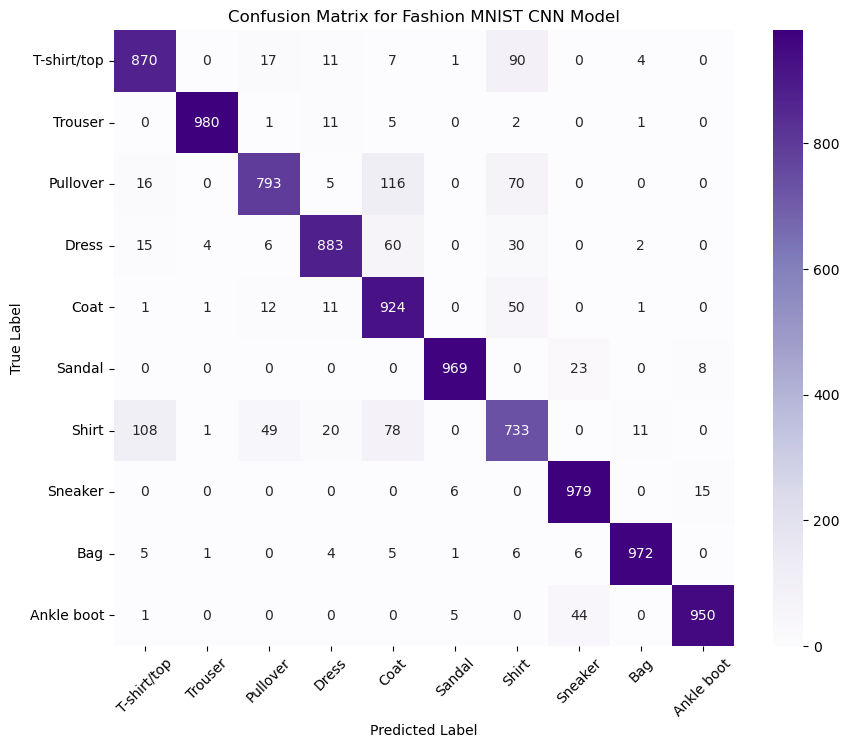

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Fashion MNIST CNN Model")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Explanation

The confusion matrix shows which clothing classes were correctly classified and which classes were confused with each other.

The values on the main diagonal represent correct predictions. Values outside the diagonal represent incorrect predictions.

This is useful for Fashion MNIST because some categories look visually similar, such as shirts, coats, and pullovers.

# Step 15: Visualize Sample Predictions

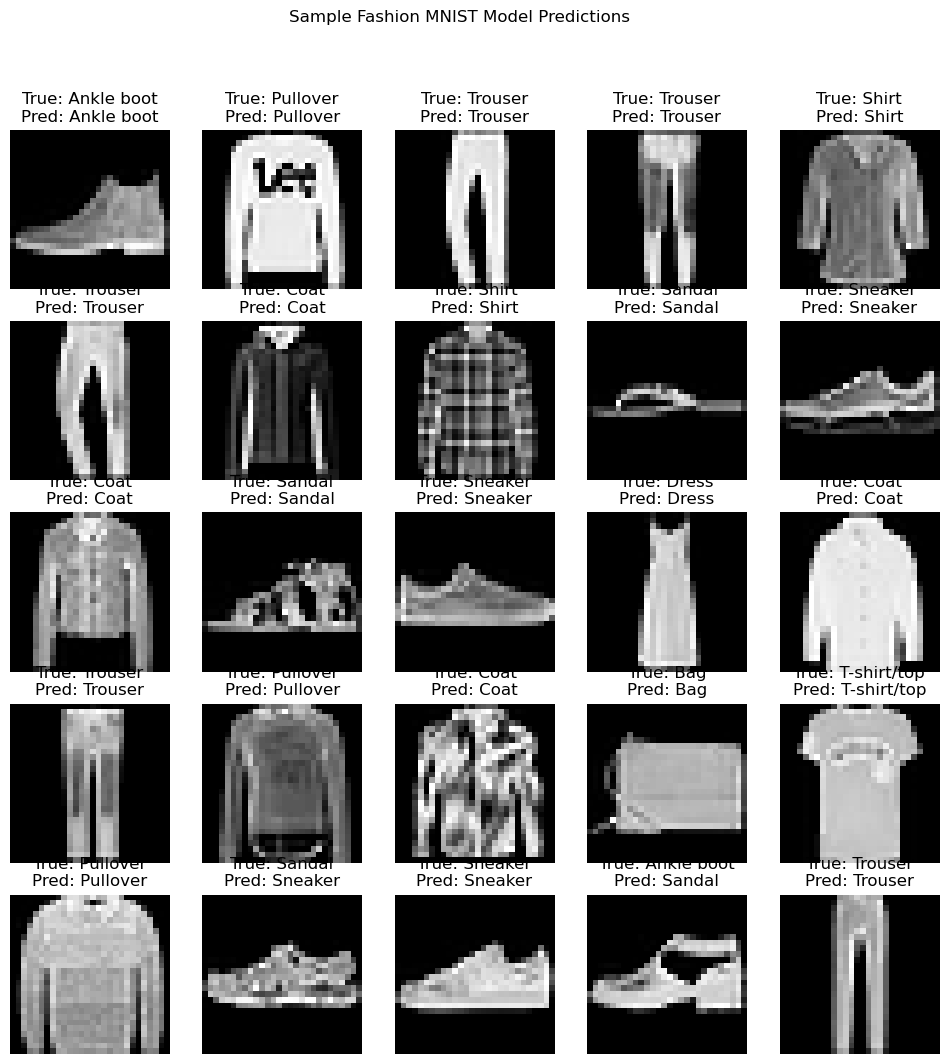

In [31]:
plt.figure(figsize=(12, 12))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"True: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}")
    plt.axis("off")

plt.suptitle("Sample Fashion MNIST Model Predictions")
plt.show()

### Explanation

This visualization shows sample test images with their true labels and predicted labels.

It helps visually confirm whether the CNN model is making reasonable predictions on unseen Fashion MNIST images.

# Step 16: Show Misclassified Images

Total test images: 10000
Correct predictions: 9053
Incorrect predictions: 947


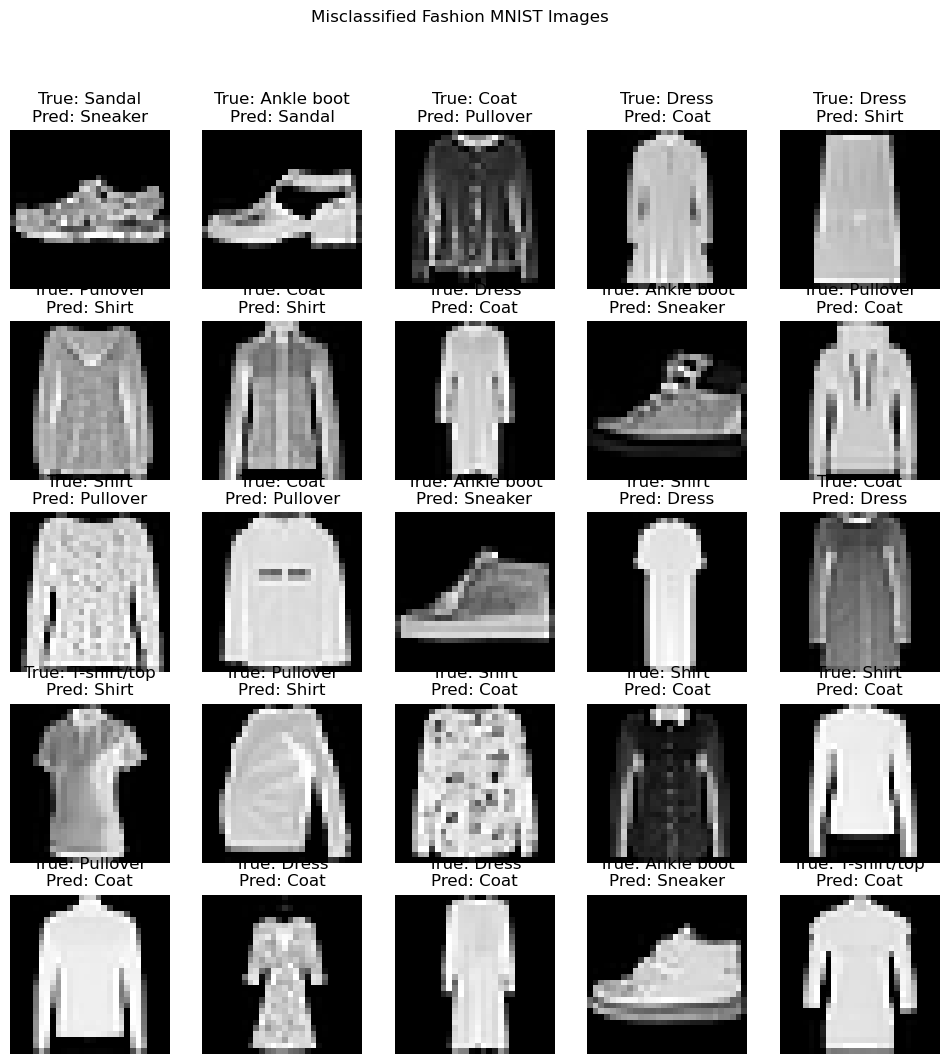

In [32]:
incorrect_indices = np.where(y_test != y_pred)[0]

print("Total test images:", len(y_test))
print("Correct predictions:", len(y_test) - len(incorrect_indices))
print("Incorrect predictions:", len(incorrect_indices))

plt.figure(figsize=(12, 12))

for i, index in enumerate(incorrect_indices[:25]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap="gray")
    plt.title(f"True: {class_names[y_test[index]]}\nPred: {class_names[y_pred[index]]}")
    plt.axis("off")

plt.suptitle("Misclassified Fashion MNIST Images")
plt.show()

### Explanation

This section displays examples where the CNN model made incorrect predictions.

Many mistakes happen between visually similar clothing categories, such as shirts, coats, and pullovers. Reviewing misclassified images helps identify the model's limitations and understand which classes are harder to classify.

# Step 17: Conclusion

This project built a CNN model to classify Fashion MNIST clothing images.

The model achieved approximately 90% test accuracy, which shows that it learned useful visual patterns from the image data.

The classification report, confusion matrix, sample predictions, and misclassified image review showed that the model performed well overall. However, some errors occurred between visually similar clothing categories, such as shirts, coats, and pullovers.

Overall, this project helped me practice image preprocessing, CNN model building, model training, model evaluation, and error analysis using TensorFlow/Keras.